In [1]:
# Import libraries               # Same
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Load the dataset               # Same
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Clean the data                 # Same
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

# Convert job_skills strings into Python lists
df["job_skills"] = df["job_skills"].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


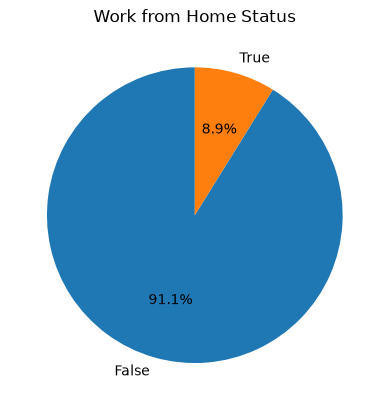

In [2]:
# Count True vs False values and plot them as a pie chart
df['job_work_from_home'].value_counts().plot(
    kind='pie',                 # Create a pie chart
    startangle=90,              # Rotate the chart 90° so it starts from the top
    autopct='%1.1f%%'           # Show percentages with 1 decimal place (e.g. 91.2%)
)

plt.title('Work from Home Status')   # Add a chart title
plt.ylabel('')                       # Remove the default y-axis label
plt.show()                           # Display the chart

In [5]:
df[['job_work_from_home', 'job_no_degree_mention', 'job_health_insurance']]

,job_work_from_home,job_no_degree_mention,job_health_insurance
0,False,False,False
1,False,False,False
2,False,False,False
3,False,True,False
4,False,False,False
...,...,...,...
785736,False,False,False
785737,False,False,False
785738,False,False,False
785739,False,False,False


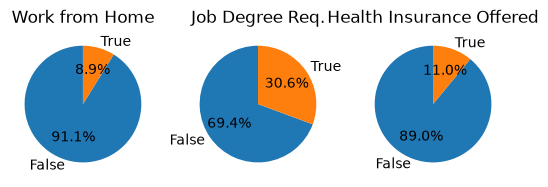

In [6]:
# Create a figure with 1 row and 3 subplots (three pie charts side by side)
fig, ax = plt.subplots(1, 3)

# Map DataFrame column names to display titles
dict_column = {
    'job_work_from_home': 'Work from Home',
    'job_no_degree_mention': 'Job Degree Req.',
    'job_health_insurance': 'Health Insurance Offered'
}

# Loop through each (column, title) pair
for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(
        df[column].value_counts(),      # Count True vs False values
        startangle=90,                  # Start the pie chart at the top (12 o'clock)
        autopct='%1.1f%%',              # Display percentages with 1 decimal place
        labels=['False', 'True']        # Labels for the two pie slices
    )
    ax[i].set_title(title)              # Set the title for this subplot

plt.show()                              # Display all three pie charts